In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import ttest_ind

In [15]:
crashes = pd.read_csv("Data/Car Accident Data 2016-2023 (CO).csv")
crashes = crashes.rename(columns={'Start_Time':'time_date','Start_Lat':'LAT','Start_Lng':'LON'})
crashes['time_date'] = pd.to_datetime(crashes['time_date'], format='mixed')

# Dangerous Times

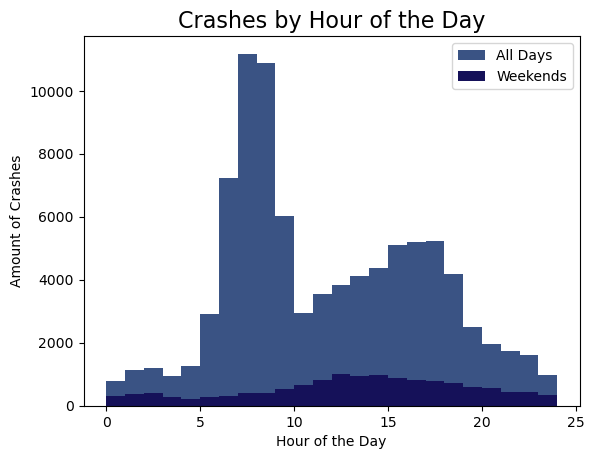

In [16]:
crashes['seconds'] = (crashes.time_date.dt.hour*3600)+(crashes.time_date.dt.minute*60)+(crashes.time_date.dt.second).astype(int)
crashes['minutes'] = crashes['seconds']/60
crashes['hours'] = crashes['seconds']/3600

weekends = crashes.loc[((crashes['time_date'].dt.dayofweek >= 5))]
plt.hist(crashes['hours'], bins=24, color = "#3a5384ff", label="All Days")
plt.hist(weekends['hours'], bins=24, color = "#151159ff", label = "Weekends")

plt.xlabel("Hour of the Day")
plt.ylabel("Amount of Crashes")
plt.title("Crashes by Hour of the Day", fontsize=16)
plt.legend()

plt.show()

Text(0.5, 1.0, 'Day of the Week')

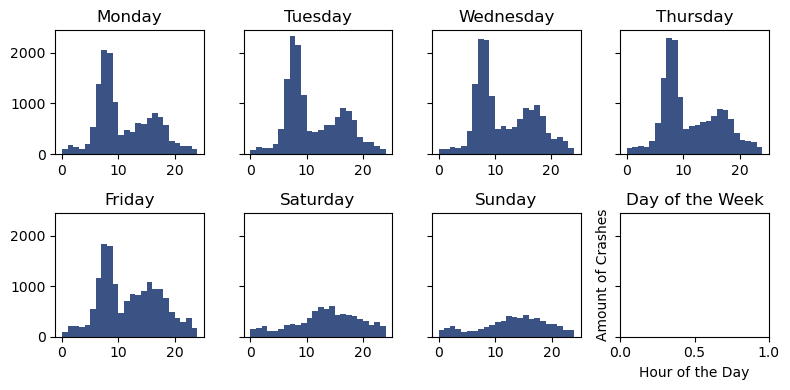

In [17]:
fig, ax = plt.subplots(2, 4, tight_layout=True, figsize=(8, 4), sharey=True)
ax[0,0].hist(crashes.loc[crashes['time_date'].dt.dayofweek==0,'hours'], bins=24,color = "#3a5384ff")    
ax[0,0].set_title("Monday")
ax[0,1].hist(crashes.loc[crashes['time_date'].dt.dayofweek==1,'hours'], bins=24,color = "#3a5384ff")    
ax[0,1].set_title("Tuesday")
ax[0,2].hist(crashes.loc[crashes['time_date'].dt.dayofweek==2,'hours'], bins=24,color = "#3a5384ff")    
ax[0,2].set_title("Wednesday")
ax[0,3].hist(crashes.loc[crashes['time_date'].dt.dayofweek==3,'hours'], bins=24,color = "#3a5384ff")    
ax[0,3].set_title("Thursday")
ax[1,0].hist(crashes.loc[crashes['time_date'].dt.dayofweek==4,'hours'], bins=24,color = "#3a5384ff")    
ax[1,0].set_title("Friday")
ax[1,1].hist(crashes.loc[crashes['time_date'].dt.dayofweek==5,'hours'], bins=24,color = "#3a5384ff")    
ax[1,1].set_title("Saturday")
ax[1,2].hist(crashes.loc[crashes['time_date'].dt.dayofweek==6,'hours'], bins=24,color = "#3a5384ff")    
ax[1,2].set_title("Sunday")
ax[1,3].set_xlabel("Hour of the Day")
ax[1,3].set_ylabel("Amount of Crashes")
ax[1,3].set_title("Day of the Week")

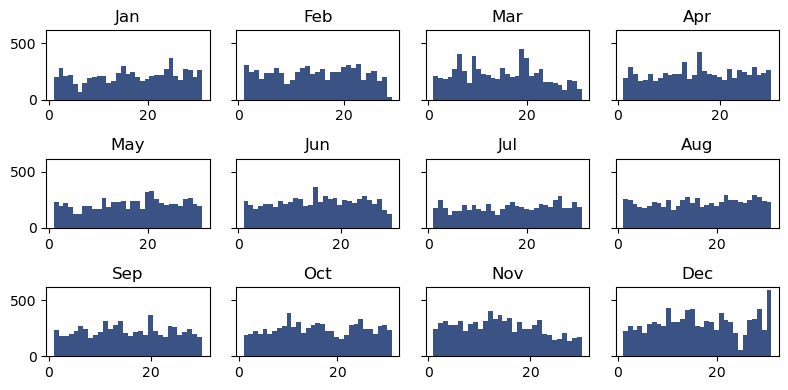

In [18]:
#Time of year. Need to make sure each month is counted same amnt of time
#Done with loop to increase readability. Otherwise wouldve been many more lines

toy = crashes.loc[((crashes['time_date']> pd.to_datetime("1/1/2017"))&(crashes['time_date'] < pd.to_datetime("1/1/2023")))]
fig, ax = plt.subplots(3, 4, tight_layout=True, figsize=(8, 4), sharey=True)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months_days = [31,29,31,30,31,30,31,31,30,31,30,31]
for i in range(12):
    ax[int(i/4), i%4].hist(toy.loc[toy['time_date'].dt.month==i+1]['time_date'].dt.day, bins=months_days[i], color = "#3a5384ff")
    ax[int(i/4), i%4].set_title(months[i])

#Notice the dip in crashes on christmas, spike before new years. See next box for exact numbers
#Left axis unlabeled below to increase readbility. 
#X axis here is day of the month, Y axis is crash count

Text(0.5, 1.0, 'December')

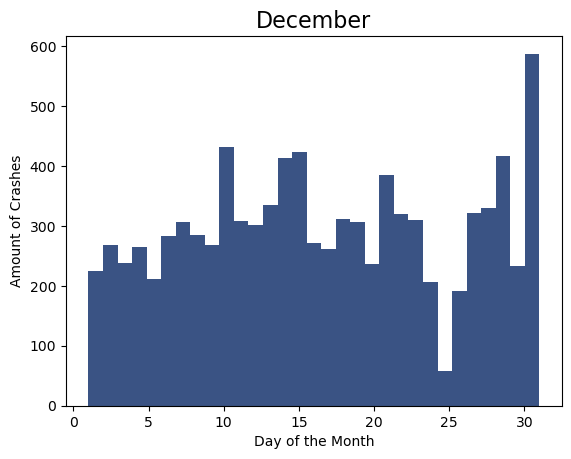

In [19]:
plt.hist(toy.loc[crashes['time_date'].dt.month==12]['time_date'].dt.day, bins=31,color = "#3a5384ff")    

plt.xlabel("Day of the Month")
plt.ylabel("Amount of Crashes")
plt.title('December',fontsize=16)

In [20]:
toy.loc[:,'day'] = toy.loc[:,'time_date'].dt.day
toy.loc[:,'month'] = toy.loc[:,'time_date'].dt.month
print("Days with fewest crashes:")
print(toy.groupby(by=['month','day']).size().sort_values().head(5))
print("Days with most crashes:")
print(toy.groupby(by=['month','day']).size().sort_values(ascending=False).head(5))

Days with fewest crashes:
month  day
2      29     22
12     25     58
1      6      71
3      28     84
       31     98
dtype: int64
Days with most crashes:
month  day
12     31     587
3      19     446
12     10     432
4      16     428
12     15     423
dtype: int64


C:\Users\eytan\AppData\Local\Temp\ipykernel_31044\53434680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toy.loc[:,'day'] = toy.loc[:,'time_date'].dt.day
C:\Users\eytan\AppData\Local\Temp\ipykernel_31044\53434680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toy.loc[:,'month'] = toy.loc[:,'time_date'].dt.month


In [21]:
print(toy.groupby(by=['month']).size().sort_values(ascending=False))

month
12    9305
11    7823
10    7588
8     7103
4     6995
3     6897
6     6885
2     6804
9     6779
5     6662
1     6659
7     5769
dtype: int64


# Dangerous Locations

In [22]:
schools = pd.read_csv("Data/Public School Info (CO).csv")

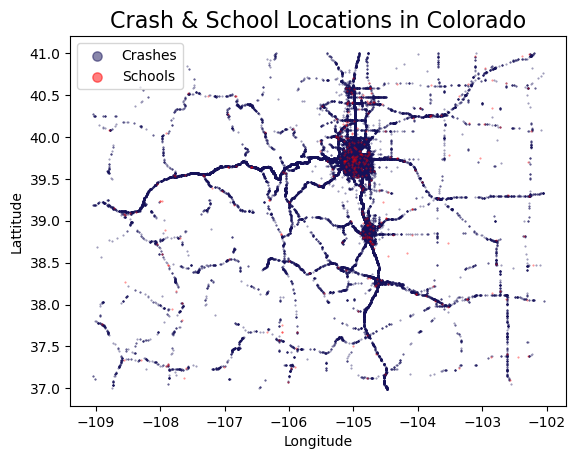

In [23]:
plt.scatter(crashes['LON'],crashes['LAT'], s=.2,alpha=.5, color = "#151159ff", label = 'Crashes')
plt.scatter(schools['LON'],schools['LAT'], s=.2, alpha=.5, color = "red", label= 'Schools')

plt.xlabel("Longitude")
plt.ylabel("Lattitude")
plt.title("Crash & School Locations in Colorado", fontsize=16)

plt.legend(markerscale=15)

plt.show()

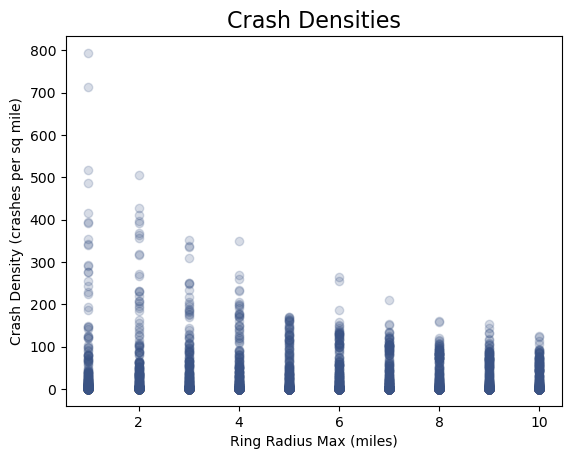

In [24]:
#Graph made using for loops. Done to help formulate the logic. See below for graph 
#made using vectorized functions
gap = 1
bins = 10
distances = np.arange(gap, gap+ gap * bins, gap)

for j in distances:
    count = np.array([])
    for i in range(schools.shape[0]):
        radius = j
        distance = (np.sqrt( \
                        (69.17*(schools['LAT'][i]-crashes['LAT']))**2+ \
                        ((69.17*np.cos(np.radians((schools['LAT'][i]+crashes['LAT']))/2)*
                        (schools['LON'][i]-crashes['LON'])))**2))
        in_range = (distance < radius) & (distance > radius-gap)
        count = np.append(count, in_range.sum())
    schools[f'r{j}'] = count
    ring_area = np.pi*(radius**2) - np.pi*((radius-gap)**2)
    schools[f'd{j}'] = (schools[f'r{j}']) / (ring_area)
    plt.scatter(np.full(schools.shape[0], radius), schools[f'd{j}'],alpha=.2, color="#3a5384ff")

plt.xlabel("Ring Radius Max (miles)")
plt.ylabel("Crash Density (crashes per sq mile)")
plt.title("Crash Densities", fontsize=16)
plt.show()

In [25]:
def density_calc(dist_data, gap=1, bins=5):
    #define radii for cutoffs
    radii = np.arange(gap, gap+ gap * bins, gap)

    #reformat data to allow for usage of built in functions
    school_lat = np.array(dist_data['LAT']).reshape(-1, 1)
    school_lon = np.array(dist_data['LON']).reshape(-1, 1)
    crash_lat = np.array(crashes['LAT'])
    crash_lon = np.array(crashes['LON'])

    #calculate distances from each school to each crash
    #Using the distance formula
    #distance between lattitude lines = 69.17 miles
    #distance between longitude line at equator = 69.17 miles, get closer further away
    #Distance between longitude lines is approxiamte, but good enough for close points, which is what we are interested in
    distances = np.sqrt(
        (69.17 * \
        (school_lat - crash_lat)) ** 2 + \
        (69.17 * np.cos(np.radians((school_lat + crash_lat) / 2)) * 
        (school_lon - crash_lon)) ** 2 \
    )  
    # 3D boolean mask - for each range
    lower_bounds = np.append(0, radii[:-1]) 
    #Need add dimension so each of the differnt bounds can be checked
    #The three dimensions are School location, crash location, radius. 
    mask = (distances[..., None] >= lower_bounds) & (distances[..., None] < radii)

    #Sum of the crashes in each ring for eah school
    crash_counts = mask.sum(axis=1)

    #Area of each ring
    areas = np.pi * (radii ** 2 - lower_bounds ** 2)

    #densities. Crashes per square mile over the 7 year period
    densities = crash_counts / areas

    #Dataframes
    crash_counts_df = pd.DataFrame(crash_counts, index=dist_data['NAME'], columns=radii)
    densities_df = pd.DataFrame(densities, index=dist_data['NAME'], columns=radii)
    return densities_df

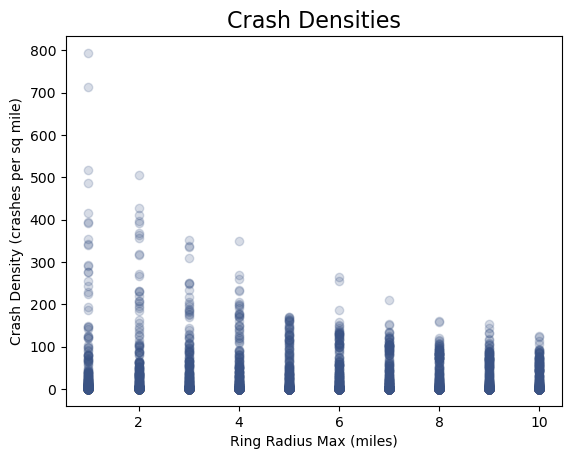

In [26]:
densities_df = pd.DataFrame()
#for loop so that ED can run the function. Running all schools through it at the asme time causes
#the kernel to crash. This loop breaks it into groups of 50.
batch_size = 50
for i in range(0, schools.shape[0], batch_size):
    new_rows = density_calc(schools.iloc[i:i + batch_size], bins=10, gap=1)
    densities_df = pd.concat([densities_df, pd.DataFrame(new_rows)])
densities_df
Y = np.array(densities_df.values.flatten(order='F').tolist())
X = np.repeat(densities_df.columns, densities_df.shape[0])
plt.scatter(X,Y, alpha=.2, color="#3a5384ff")

plt.xlabel("Ring Radius Max (miles)")
plt.ylabel("Crash Density (crashes per sq mile)")
plt.title("Crash Densities", fontsize=16)
plt.show()

In [27]:
print(densities_df[1].sort_values(ascending=False).head(3))
print(densities_df[2].sort_values(ascending=False).head(3))
print(densities_df[3].sort_values(ascending=False).head(3))

NAME
Florence Crittenton High School                 793.864856
Colorado High School Charter                    714.287385
Girls Athletic Leadership School High School    516.298635
Name: 1, dtype: float64
NAME
West High School              504.733376
DSST: Cole High School        427.277971
Denver Justice High School    411.044166
Name: 2, dtype: float64
NAME
Emily Griffith High School             351.732424
North High School Engagement Center    337.153831
North High School                      335.880592
Name: 3, dtype: float64


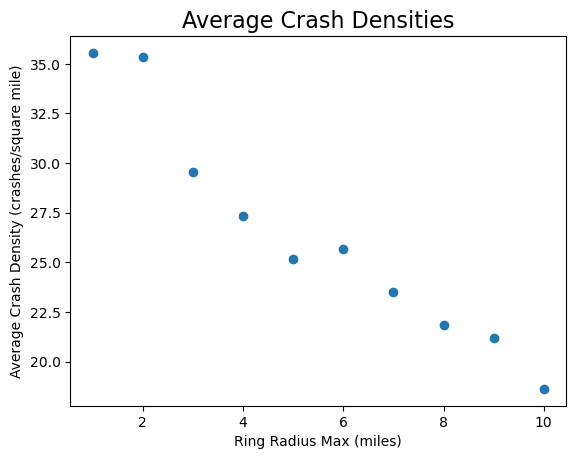

In [28]:
plt.scatter(densities_df.columns,densities_df.mean())
plt.xlabel("Ring Radius Max (miles)")
plt.ylabel("Average Crash Density (crashes/square mile)")
plt.title("Average Crash Densities", fontsize=16)
plt.show()

# Dangerous Conditions

In [29]:
synthetic = pd.read_csv("Data/Synthetic Data.csv")
synthetic = synthetic.dropna()

crashes_flr = crashes[['time_date', 'LAT', 'LON', 'Temperature(F)', 'Wind_Chill(F)', \
                       'Humidity(%)', 'Wind_Speed(mph)', 'Precipitation(in)']]
crashes_flr = crashes_flr.dropna(ignore_index=True)

In [30]:
#Bring in synthetic data and format
synthetic['time'] = pd.to_datetime(synthetic['time'], format='mixed')
synthetic = synthetic[['time', 'latitude', 'longitude', 'temperature_2m', 'apparent_temperature','relative_humidity_2m', 'wind_speed_10m', 'precipitation']]
synthetic.columns = crashes_flr.columns

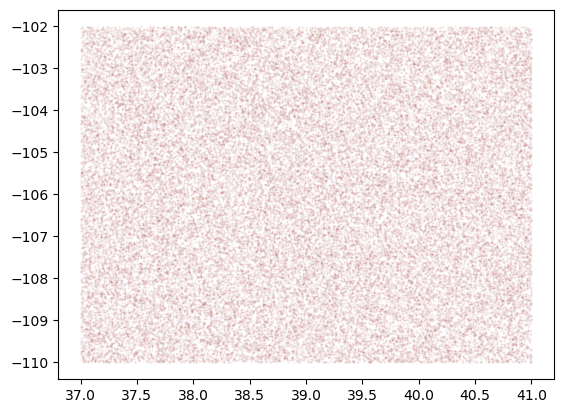

In [31]:
#confirmation that the synthetic data is random
plt.scatter(synthetic['LAT'], synthetic['LON'], s=.2, alpha=.1, color = "#911313")
plt.show()

In [32]:
#combine the data into one dataframe
crashes_flr['is_crash'] = 1
synthetic['is_crash'] = 0
data = pd.concat([crashes_flr,synthetic])
data.reset_index(drop=True, inplace=True)
data[data.columns[8]]

0         1
1         1
2         1
3         1
4         1
         ..
119115    0
119116    0
119117    0
119118    0
119119    0
Name: is_crash, Length: 119120, dtype: int64

In [33]:
#is there a statistical dif between the groups? (t-stat and p-value)
t = []
p = []
for i in range(5):
    t_stat, p_value =  ttest_ind(crashes_flr.iloc[:,i+3], synthetic.iloc[:,i+3])
    t.append(t_stat)
    p.append(p_value)
    print("{}:   t = {}, p = {}".format(data.columns[i+3],t[i],p[i]))


Temperature(F):   t = 9.290974396890492, p = 1.5534673020563567e-20
Wind_Chill(F):   t = 32.31335022918935, p = 4.4376800757512434e-228
Humidity(%):   t = 6.495883927989062, p = 8.287079087806027e-11
Wind_Speed(mph):   t = 34.99555359733341, p = 6.022837821952171e-267
Precipitation(in):   t = -8.765766324606078, p = 1.8788269625849176e-18


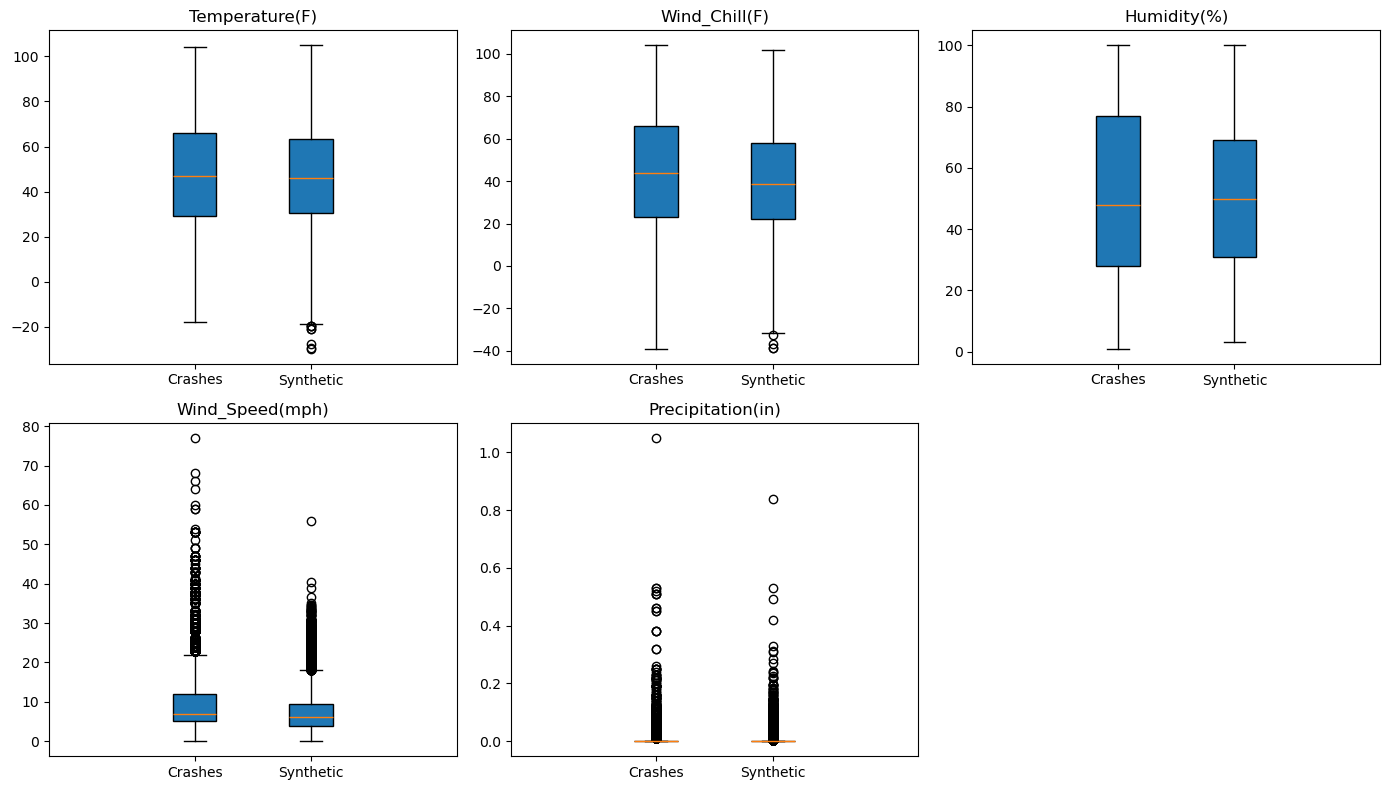

In [34]:
fig, ax = plt.subplots(2,3, figsize=(14, 8), tight_layout=True)
#box = ax.boxplot(data, patch_artist=True, labels=["Group 1", "Group 2"])
for i in range(5):
    ax[int(i/3), i%3].set_title(crashes_flr.columns[i+3])
    ax[int(i/3), i%3].boxplot(crashes_flr.iloc[:,i+3], positions=[.8], patch_artist=True, )
    ax[int(i/3), i%3].boxplot(synthetic.iloc[:,i+3], positions=[1.2],patch_artist=True)
    ax[int(i/3), i%3].set_xticklabels(['Crashes', 'Synthetic'])    
fig.delaxes(ax[1, 2])          

In [35]:
Train, Test = train_test_split(data,train_size=.6, shuffle=True)
#['time_date', 'LAT', 'LON', 'Temperature(F)', 'Wind_Chill(F)','Humidity(%)', 'Wind_Speed(mph)', 'Precipitation(in)', 'is_crash']
Predictors = ['Wind_Chill(F)','Humidity(%)', 'Wind_Speed(mph)', 'Precipitation(in)']
Outcome = 'is_crash'
LR = LogisticRegression()
LR.fit(Train[Predictors], Train[Outcome])


LogisticRegression()

In [36]:
predictions = LR.predict(Test[Predictors])
# Calculate accuracy
accuracy = accuracy_score(Test[Outcome], predictions)
print("Accuracy = {}".format(accuracy))

beta_values = LR.coef_  
intercept = LR.intercept_
conf_matrix = confusion_matrix(Test[Outcome], predictions)

print("Intercept = {}".format(intercept))
print("Predictors = {}".format(Predictors))
print("Beta Values = {}".format(beta_values))
print("Odds increase per unit change = {}".format(np.exp(beta_values)))
print(conf_matrix)

Accuracy = 0.5809267965077233
Intercept = [-1.53651252]
Predictors = ['Wind_Chill(F)', 'Humidity(%)', 'Wind_Speed(mph)', 'Precipitation(in)']
Beta Values = [[ 0.01501435  0.0126007   0.04470049 -5.67346475]]
Odds increase per unit change = [[1.01512763 1.01268042 1.04571461 0.00343594]]
[[11787 11133]
 [ 8835 15893]]


In [37]:
#rerun since the rain doesn't make intuitive sense
Predictors = ['Wind_Chill(F)','Humidity(%)', 'Wind_Speed(mph)']
LR.fit(Train[Predictors], Train[Outcome])

predictions = LR.predict(Test[Predictors])
# Calculate accuracy
accuracy = accuracy_score(Test[Outcome], predictions)
print("Accuracy = {}".format(accuracy))

beta_values = LR.coef_  
intercept = LR.intercept_
conf_matrix = confusion_matrix(Test[Outcome], predictions)

print("Intercept = {}".format(intercept))
print("Predictors = {}".format(Predictors))
print("Beta Values = {}".format(beta_values))
print("Odds increase per unit change = {}".format(np.exp(beta_values)))
print("Confusion Matrix: \n {}".format(conf_matrix))

Accuracy = 0.5781145063801209
Intercept = [-1.49444943]
Predictors = ['Wind_Chill(F)', 'Humidity(%)', 'Wind_Speed(mph)']
Beta Values = [[0.01475477 0.01196145 0.04368298]]
Odds increase per unit change = [[1.01486416 1.01203327 1.04465113]]
Confusion Matrix: 
 [[11671 11249]
 [ 8853 15875]]


In [38]:
 tree1 = DecisionTreeClassifier(min_samples_leaf=1, random_state=12)
 tree2 = DecisionTreeClassifier(min_samples_leaf=20, random_state=12)
 tree3 = DecisionTreeClassifier(min_samples_leaf=60, random_state=12) 

 tree1.fit(Train[Predictors], Train[Outcome])
 tree2.fit(Train[Predictors], Train[Outcome])
 tree3.fit(Train[Predictors], Train[Outcome])

DecisionTreeClassifier(min_samples_leaf=60, random_state=12)

In [39]:
 print("Tree1: " + str(tree1.score(Train[Predictors], Train[Outcome])) + ", " + str(tree1.score(Test[Predictors], Test[Outcome])))
 print("Tree2: " + str(tree2.score(Train[Predictors], Train[Outcome])) + ", " + str(tree2.score(Test[Predictors], Test[Outcome])))
 print("Tree3: " + str(tree3.score(Train[Predictors], Train[Outcome])) + ", " + str(tree3.score(Test[Predictors], Test[Outcome])))
 #results seem too good. I expect the model is really detecting the different sources of information instead
 #of truly using the inputs to predict outcomes.

Tree1: 0.9992864338482202, 0.959599563465413
Tree2: 0.9597744571300649, 0.9562625923438549
Tree3: 0.9560387284531006, 0.9542478173270651


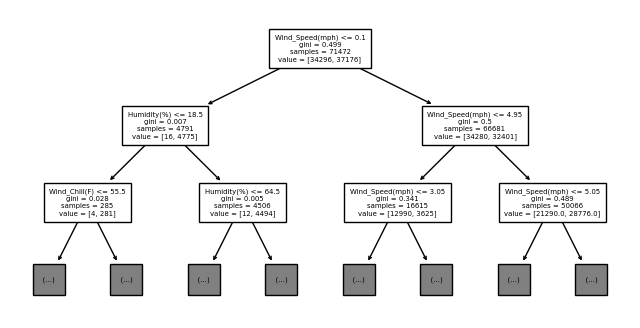

In [40]:
plt.figure(figsize=(8,4))
plot_tree(tree3,max_depth=2,fontsize=5,feature_names= Predictors)
plt.show()